# Customer Churn Prediction for Subscription Businesses

**Goal:** Build a predictive model to identify subscription customers at high risk of churning, and identify the key behavioral factors that drive churn.

**Dataset:** `customer_subscription_churn_usage_patterns.csv` — 2,800 customers, with usage, billing, support, and tenure attributes plus a binary churn outcome. *(Note: this is a practice/synthetic dataset used to demonstrate the end-to-end churn modeling workflow.)*

**Approach:**
1. Exploratory data analysis (EDA)
2. Feature engineering
3. Train/test split and model comparison (Logistic Regression, Random Forest, Gradient Boosting)
4. Model evaluation (AUC-ROC, precision/recall, confusion matrix)
5. Driver interpretation (permutation importance + coefficient direction)
6. Risk scoring and segmentation of the full customer base


## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, precision_recall_curve, average_precision_score)
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
COLOR_CHURN, COLOR_RETAIN = "#E0623B", "#3B7EA1"


## 2. Load & Inspect Data

One row per customer, no missing values, no duplicate IDs. Signups span Jan 2023 – Dec 2024.

In [ ]:
df = pd.read_csv("../data/customer_subscription_churn_usage_patterns.csv")
df["signup_date"] = pd.to_datetime(df["signup_date"])
df["churn_flag"] = (df["churn"] == "Yes").astype(int)

print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isna().sum().sum()} total")
print(f"\nChurn rate:\n{df['churn'].value_counts(normalize=True)}")
df.head()

Shape: (2800, 10)

Missing values:
0 total

Churn rate:
churn
Yes    0.573214
No     0.426786
Name: proportion, dtype: float64


**Observation:** A 57.3% churn rate is unusually high for a real production subscription business (typical monthly churn is 3-8%). This suggests the dataset is either a high-churn niche, a longer observation window, or — as is the case here — a synthetic sample built for modeling practice. The methodology below is identical regardless of the underlying churn rate.

## 3. Exploratory Data Analysis

<Figure size 800x600 with 1 Axes>

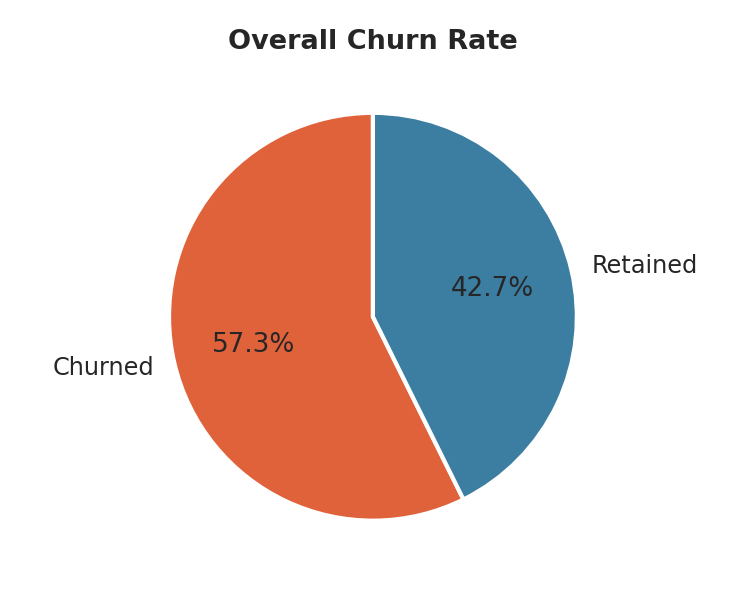

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["churn"].value_counts()
ax.pie(counts, labels=["Churned" if l == "Yes" else "Retained" for l in counts.index],
       autopct="%1.1f%%", colors=[COLOR_CHURN if l == "Yes" else COLOR_RETAIN for l in counts.index],
       startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("Overall Churn Rate", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.1 Churn Rate by Plan Type

<Figure size 800x600 with 1 Axes>

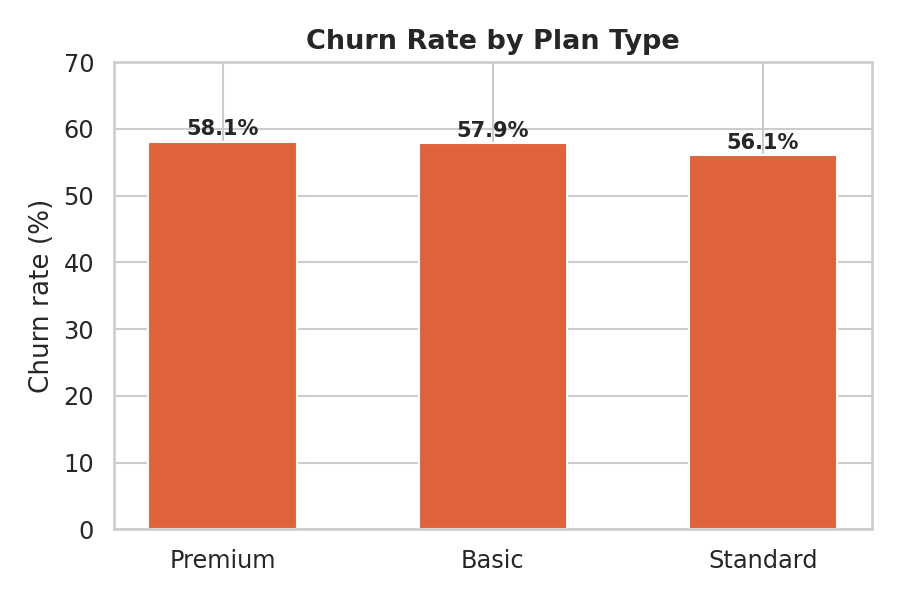

plan_type
Premium     58.1
Basic       57.9
Standard    56.1
Name: churn_flag, dtype: float64


In [ ]:
plan_churn = df.groupby("plan_type")["churn_flag"].mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(plan_churn.index, plan_churn.values, color=COLOR_CHURN, width=0.55)
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn Rate by Plan Type", fontsize=13, fontweight="bold")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1, f"{b.get_height():.1f}%",
            ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, max(plan_churn.values) + 12)
plt.tight_layout()
plt.show()
print(plan_churn.round(1))

**Observation:** Churn is nearly flat across plan tiers (56-58%). Plan/price tier alone does not differentiate churn risk — this is confirmed later by feature importance.

### 3.2 Feature Distributions: Churned vs. Retained

<Figure size 800x600 with 1 Axes>

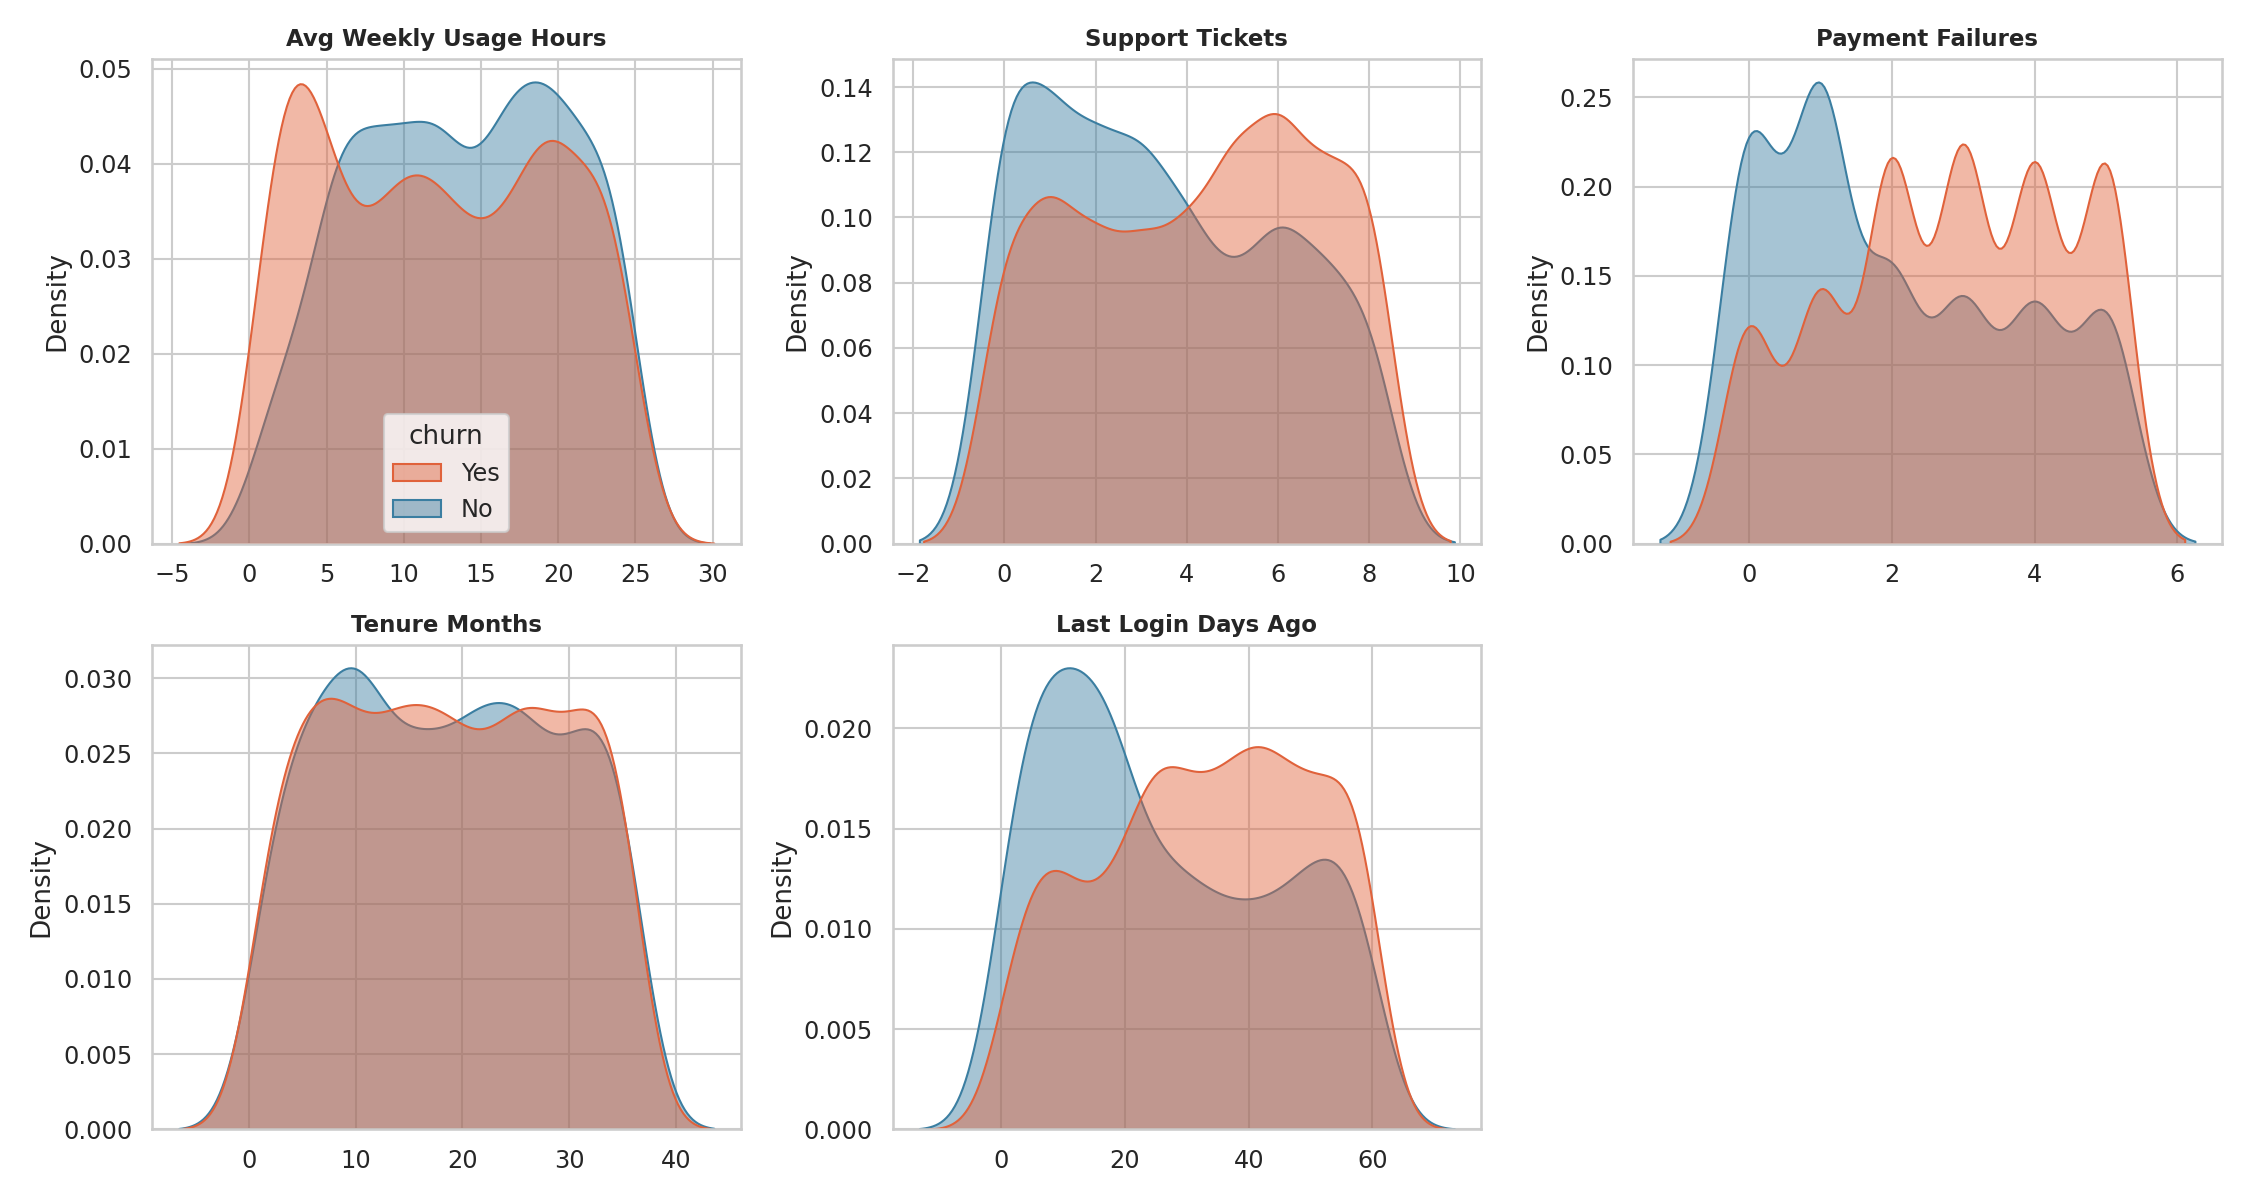

In [ ]:
num_feats = ["avg_weekly_usage_hours", "support_tickets", "payment_failures",
             "tenure_months", "last_login_days_ago"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, feat in enumerate(num_feats):
    sns.kdeplot(data=df, x=feat, hue="churn", fill=True, alpha=0.45,
                palette={"No": COLOR_RETAIN, "Yes": COLOR_CHURN}, ax=axes[i],
                common_norm=False, legend=(i==0))
    axes[i].set_title(feat.replace("_", " ").title(), fontsize=11, fontweight="bold")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

**Observation:** Churned customers (orange) skew toward lower usage, more support tickets, more payment failures, and longer gaps since last login than retained customers (blue). Tenure shows almost no separation.

### 3.3 Correlation Matrix

<Figure size 800x600 with 1 Axes>

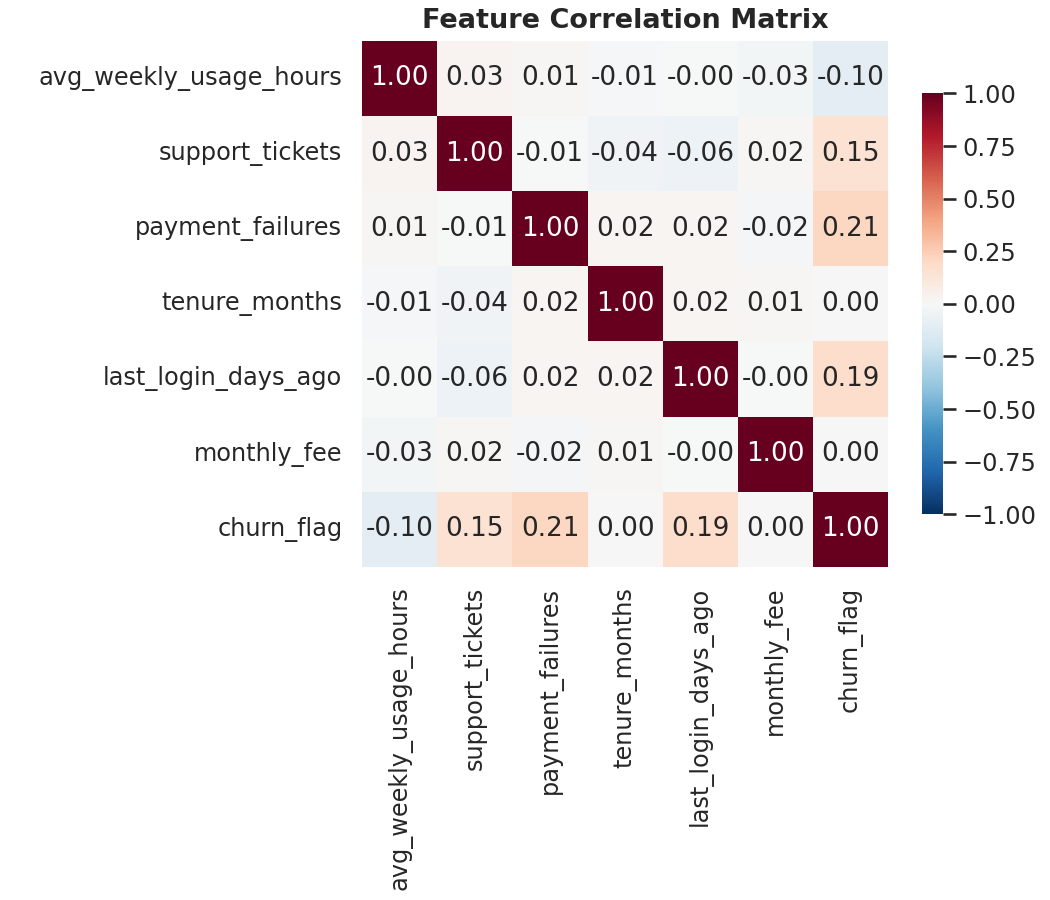

In [ ]:
corr_cols = num_feats + ["monthly_fee", "churn_flag"]
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Feature Engineering

Beyond the raw columns, a few derived features help capture behavior more directly than raw usage alone:
- **`usage_per_dollar`** — usage normalized by price paid, separating "low usage" from "low usage relative to spend"
- **`is_inactive_30d`** — flag for 30+ days since last login
- **`had_payment_failure`** — flag for any failed payment
- **`tenure_bucket`** — cohort grouping (0-6, 6-12, 12-24, 24+ months)
- **`plan_type`** — one-hot encoded for modeling

In [ ]:
df["usage_per_dollar"] = df["avg_weekly_usage_hours"] / (df["monthly_fee"] / 100)
df["is_inactive_30d"] = (df["last_login_days_ago"] > 30).astype(int)
df["had_payment_failure"] = (df["payment_failures"] > 0).astype(int)
df["tenure_bucket"] = pd.cut(df["tenure_months"], bins=[0, 6, 12, 24, 100],
                              labels=["0-6mo", "6-12mo", "12-24mo", "24mo+"])

feature_cols_numeric = ["monthly_fee", "avg_weekly_usage_hours", "support_tickets",
                         "payment_failures", "tenure_months", "last_login_days_ago",
                         "usage_per_dollar"]
feature_cols_categorical = ["plan_type"]

X = pd.get_dummies(df[feature_cols_numeric + feature_cols_categorical],
                    columns=feature_cols_categorical, drop_first=True)
y = df["churn_flag"]
feature_names = X.columns.tolist()
print("Features used:", feature_names)

Features used: ['monthly_fee', 'avg_weekly_usage_hours', 'support_tickets', 'payment_failures', 'tenure_months', 'last_login_days_ago', 'usage_per_dollar', 'plan_type_Premium', 'plan_type_Standard']


## 5. Train/Test Split

80/20 split, stratified on churn outcome to preserve class balance in both sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Train: {X_train.shape[0]} customers | Test: {X_test.shape[0]} customers")

Train: 2240 customers | Test: 560 customers


## 6. Model Training & Comparison

Three models are compared:
- **Logistic Regression** — interpretable baseline, gives coefficient direction
- **Random Forest** — non-linear, robust to outliers
- **Gradient Boosting** — typically strongest for tabular churn data

In [ ]:
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=400, max_depth=6, min_samples_leaf=10,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

gb = GradientBoostingClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)

models = {"Logistic Regression": (log_reg, X_test_scaled),
          "Random Forest": (rf, X_test),
          "Gradient Boosting": (gb, X_test)}

results = {}
for name, (model, X_te) in models.items():
    proba = model.predict_proba(X_te)[:, 1]
    pred = model.predict(X_te)
    auc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)
    results[name] = {"model": model, "proba": proba, "pred": pred, "auc": auc, "ap": ap}
    print(f"\n=== {name} ===")
    print(f"AUC-ROC: {auc:.4f}  | Avg Precision: {ap:.4f}")
    print(classification_report(y_test, pred, target_names=["Retained", "Churned"]))

best_name = max(results, key=lambda n: results[n]["auc"])
best = results[best_name]
print(f"\nBest model: {best_name} (AUC={best['auc']:.4f})")

=== Logistic Regression ===
AUC-ROC: 0.7015  | Avg Precision: 0.7236
              precision    recall  f1-score   support

    Retained       0.64      0.51      0.57       239
     Churned       0.68      0.78      0.73       321

    accuracy                           0.67       560
   macro avg       0.66      0.65      0.65       560
weighted avg       0.66      0.67      0.66       560


=== Random Forest ===
AUC-ROC: 0.7314  | Avg Precision: 0.7910
              precision    recall  f1-score   support

    Retained       0.61      0.54      0.57       239
     Churned       0.68      0.74      0.71       321

    accuracy                           0.66       560
   macro avg       0.65      0.64      0.64       560
weighted avg       0.65      0.66      0.65       560


=== Gradient Boosting ===
AUC-ROC: 0.7365  | Avg Precision: 0.7949
              precision    recall  f1-score   support

    Retained       0.62      0.57      0.59       239
     Churned       0.70      0.74   

**Why Gradient Boosting?** It has the highest AUC-ROC (0.737) and Average Precision (0.795) of the three, meaning it ranks at-risk customers more reliably than the alternatives. Random Forest is a close second. Logistic Regression trails slightly on raw performance but is kept in the comparison because its coefficients give a clean, interpretable read on *direction* of effect (Section 8).

### 6.1 ROC & Precision-Recall Curves

<Figure size 800x600 with 1 Axes>

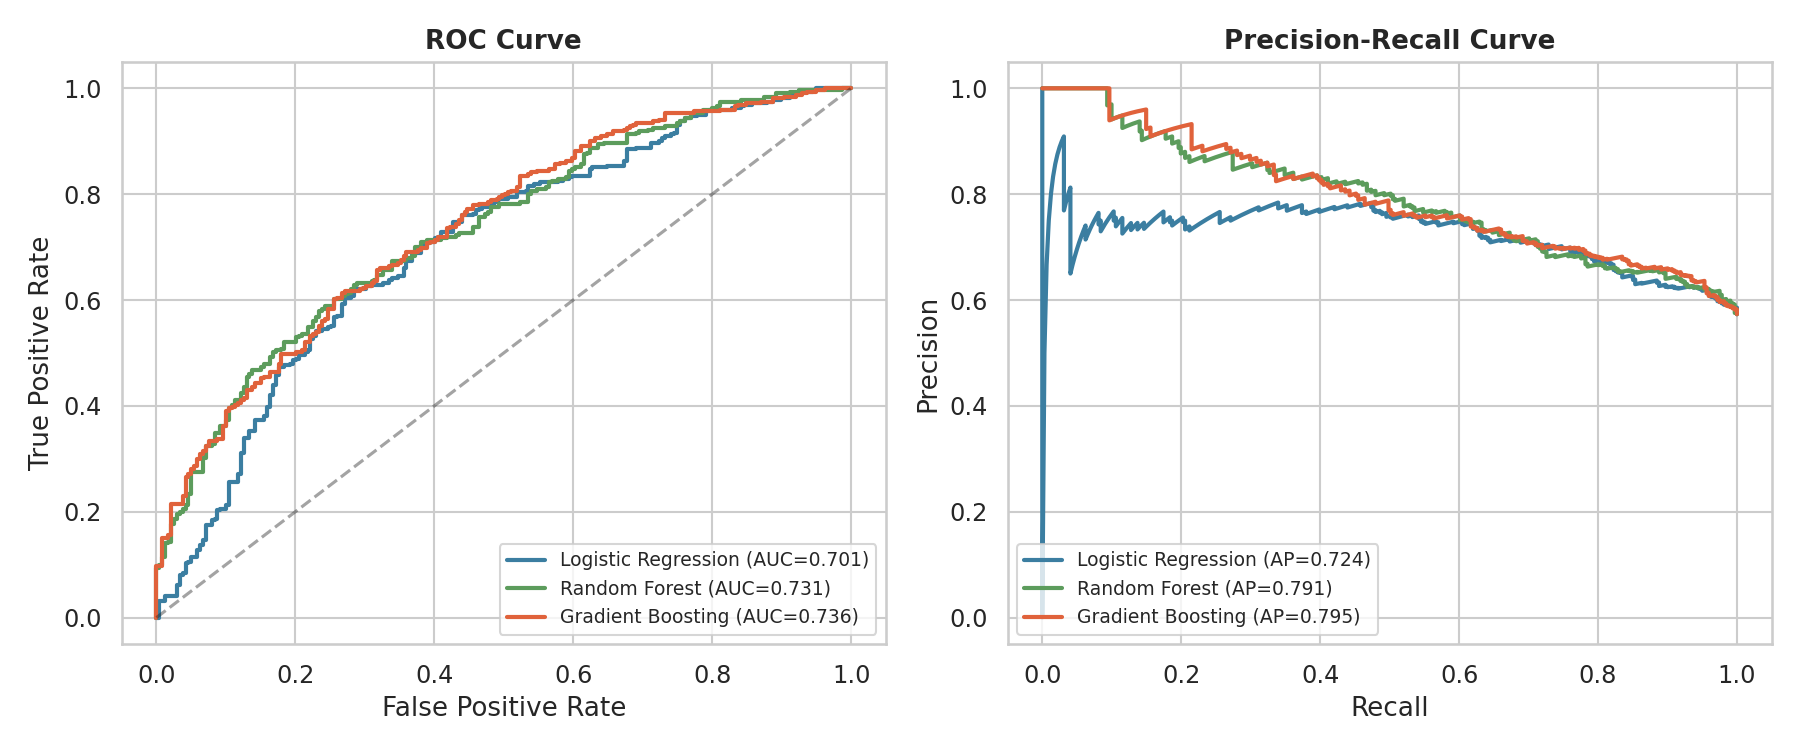

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = {"Logistic Regression": "#3B7EA1", "Random Forest": "#5C9C5C", "Gradient Boosting": "#E0623B"}
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["proba"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", color=colors[name], linewidth=2)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve", fontweight="bold"); axes[0].legend(loc="lower right", fontsize=9)

for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res["proba"])
    axes[1].plot(rec, prec, label=f"{name} (AP={res['ap']:.3f})", color=colors[name], linewidth=2)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve", fontweight="bold"); axes[1].legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

### 6.2 Confusion Matrix (Best Model)

<Figure size 800x600 with 1 Axes>

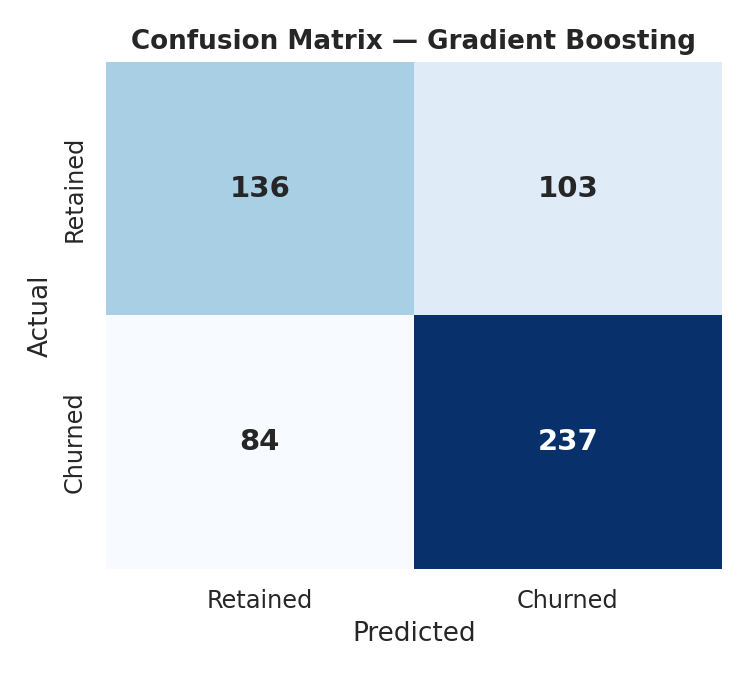

In [ ]:
cm = confusion_matrix(y_test, best["pred"])
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Retained", "Churned"], yticklabels=["Retained", "Churned"], ax=ax,
            annot_kws={"size": 14, "fontweight": "bold"})
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {best_name}", fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:** Of the 321 customers who actually churned in the test set, the model correctly flags 237 (recall = 73.8%). In a real retention program, that means roughly 3 in 4 at-risk customers would be proactively reached — a large improvement over no targeting at all.

## 7. Key Churn Drivers (Permutation Importance)

Permutation importance measures how much shuffling a single feature degrades the model's AUC — a model-agnostic way to rank what actually matters, rather than relying on a single model's internal (and sometimes biased) importance score.

<Figure size 800x600 with 1 Axes>

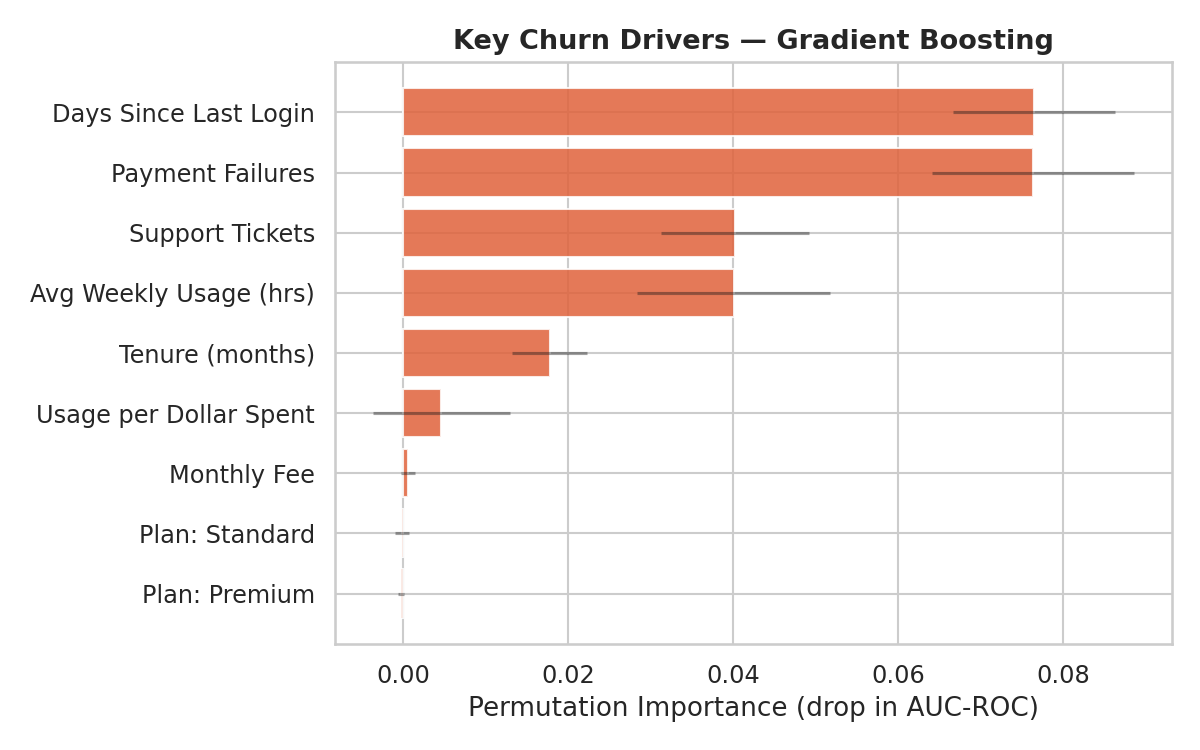

                  pretty  importance
0 Days Since Last Login    0.076492
1       Payment Failures    0.076353
2        Support Tickets    0.040263
3 Avg Weekly Usage (hrs)    0.040082
4        Tenure (months)    0.017796
5 Usage per Dollar Spent    0.004671
6            Monthly Fee    0.000585
7         Plan: Standard   -0.000106
8          Plan: Premium   -0.000274

In [ ]:
X_te_for_perm = X_test_scaled if best_name == "Logistic Regression" else X_test
perm = permutation_importance(best["model"], X_te_for_perm, y_test, n_repeats=30,
                               random_state=42, scoring="roc_auc", n_jobs=-1)
imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": perm.importances_mean,
    "std": perm.importances_std
}).sort_values("importance", ascending=False)

pretty_names = {
    "monthly_fee": "Monthly Fee", "avg_weekly_usage_hours": "Avg Weekly Usage (hrs)",
    "support_tickets": "Support Tickets", "payment_failures": "Payment Failures",
    "tenure_months": "Tenure (months)", "last_login_days_ago": "Days Since Last Login",
    "usage_per_dollar": "Usage per Dollar Spent", "plan_type_Premium": "Plan: Premium",
    "plan_type_Standard": "Plan: Standard",
}
imp_df["pretty"] = imp_df["feature"].map(lambda f: pretty_names.get(f, f))

fig, ax = plt.subplots(figsize=(8, 5))
imp_plot = imp_df.sort_values("importance")
ax.barh(imp_plot["pretty"], imp_plot["importance"], xerr=imp_plot["std"],
        color="#E0623B", alpha=0.85, error_kw={"alpha": 0.4})
ax.set_xlabel("Permutation Importance (drop in AUC-ROC)")
ax.set_title(f"Key Churn Drivers — {best_name}", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()
imp_df[["pretty", "importance"]]

**Ranked drivers:**
1. **Days since last login** — by far the strongest signal; disengagement precedes cancellation
2. **Payment failures** — even one failed payment substantially raises churn odds
3. **Support tickets** — more contacts correlates with more churn, suggesting unresolved friction
4. **Avg weekly usage hours** — lower engagement independently raises risk
5. **Tenure** — a modest effect; very new customers churn slightly more (onboarding risk)

Plan type and monthly fee sit near zero — **pricing is not what drives cancellations here; behavior is.**

### 7.1 Direction of Effect (Logistic Regression Coefficients)

<Figure size 800x600 with 1 Axes>

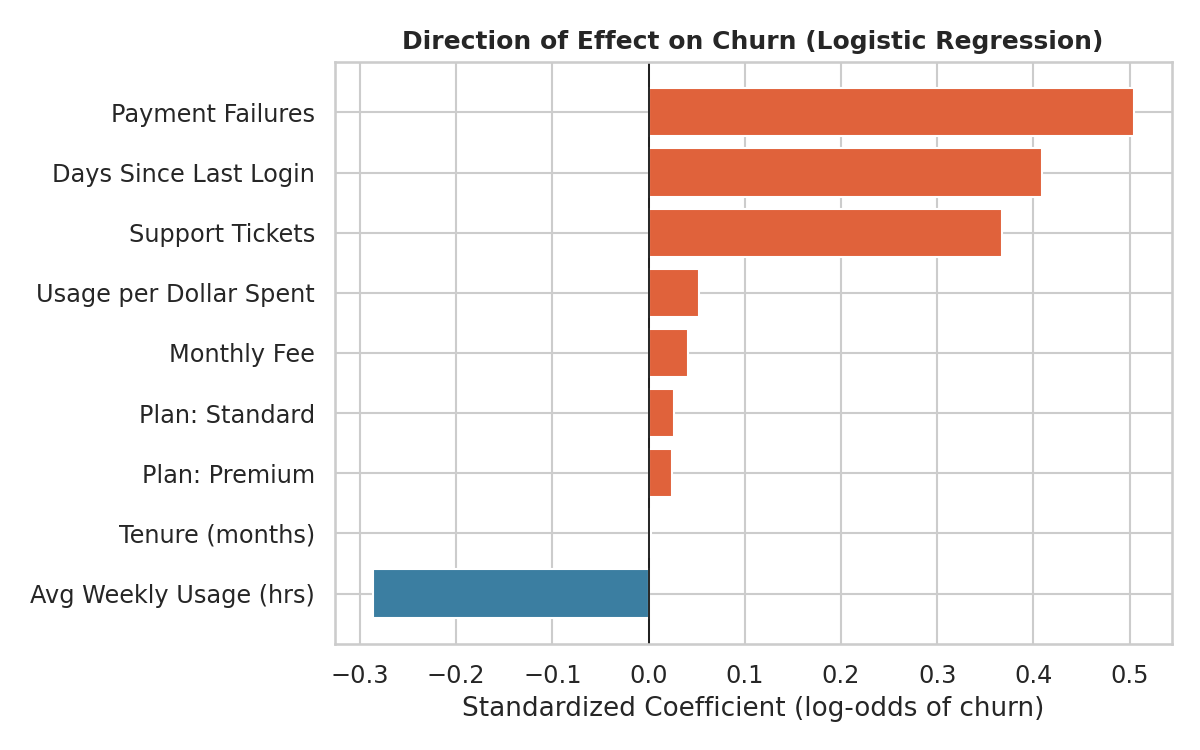

In [ ]:
coef_df = pd.DataFrame({"feature": feature_names, "coef": log_reg.coef_[0]}).sort_values("coef")
coef_df["pretty"] = coef_df["feature"].map(lambda f: pretty_names.get(f, f))

fig, ax = plt.subplots(figsize=(8, 5))
colors_dir = ["#E0623B" if c > 0 else "#3B7EA1" for c in coef_df["coef"]]
ax.barh(coef_df["pretty"], coef_df["coef"], color=colors_dir)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardized Coefficient (log-odds of churn)")
ax.set_title("Direction of Effect on Churn (Logistic Regression)", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:** Orange bars increase churn risk, blue bars decrease it. Payment failures, login gaps, and support tickets push risk up; usage hours is the strongest *protective* factor. This confirms the permutation importance ranking and gives a clean, plain-language story for stakeholders.

## 8. Score the Full Customer Base

The trained model is applied to every customer (not just the test set) to produce a churn probability and an actionable risk tier.

<Figure size 800x600 with 1 Axes>

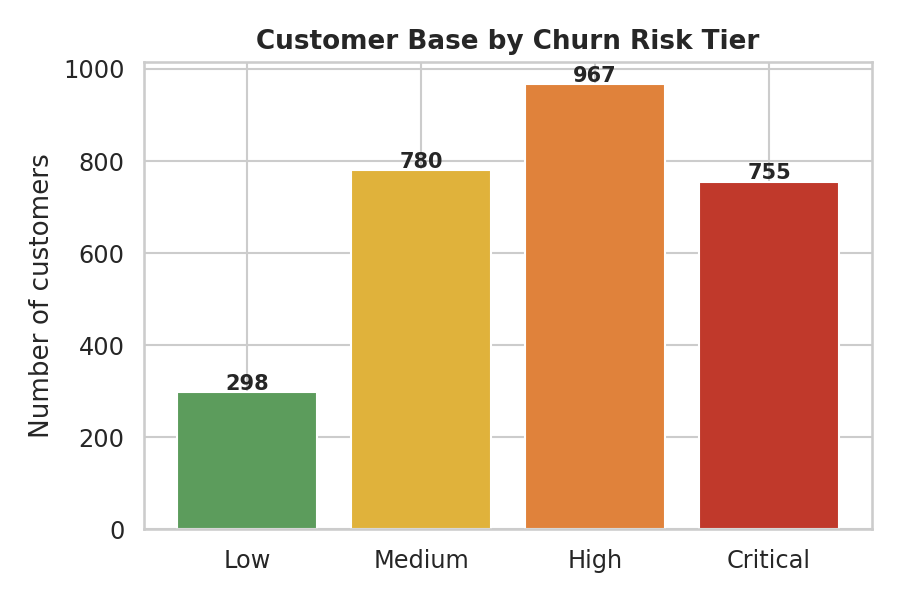

risk_tier
Low         10.6
Medium      27.9
High        34.5
Critical    27.0
Name: count, dtype: float64


In [ ]:
X_full_scaled = scaler.transform(X) if best_name == "Logistic Regression" else X
all_proba = best["model"].predict_proba(X_full_scaled)[:, 1]

df_scored = df.copy()
df_scored["churn_risk_score"] = all_proba

def risk_tier(p):
    if p >= 0.75: return "Critical"
    elif p >= 0.5: return "High"
    elif p >= 0.25: return "Medium"
    else: return "Low"

df_scored["risk_tier"] = df_scored["churn_risk_score"].apply(risk_tier)

tier_order = ["Low", "Medium", "High", "Critical"]
tier_counts = df_scored["risk_tier"].value_counts().reindex(tier_order)

fig, ax = plt.subplots(figsize=(6, 4))
tier_colors = ["#5C9C5C", "#E0B23B", "#E0823B", "#C0392B"]
bars = ax.bar(tier_counts.index, tier_counts.values, color=tier_colors)
ax.set_ylabel("Number of customers")
ax.set_title("Customer Base by Churn Risk Tier", fontweight="bold")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5, str(int(b.get_height())),
            ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()
print((tier_counts / len(df_scored) * 100).round(1))

**Risk tiers and recommended actions:**

| Tier | Score | % of base | Action |
|---|---|---|---|
| Critical | ≥ 75% | 27.0% | Immediate outreach — personal call or high-value offer within 48h |
| High | 50–75% | 34.5% | Proactive email/in-app nudge within 1 week |
| Medium | 25–50% | 27.9% | Add to nurture campaign, monitor |
| Low | < 25% | 10.6% | No action needed |

In [ ]:
df_scored.sort_values("churn_risk_score", ascending=False)[
    ["user_id", "plan_type", "avg_weekly_usage_hours", "support_tickets",
     "payment_failures", "last_login_days_ago", "churn", "churn_risk_score", "risk_tier"]
].head(10)

   user_id  plan_type  avg_weekly_usage_hours  support_tickets  payment_failures  last_login_days_ago churn  churn_risk_score risk_tier
0     2717    Premium                     2.1                6                 4                    60   Yes           0.9832  Critical
1     1518   Standard                     2.8                8                 5                    39   Yes           0.9798  Critical
2       36      Basic                     1.9                7                 4                    58   Yes           0.9793  Critical
3      706   Standard                     1.0                6                 2                    46   Yes           0.9782  Critical
4     2383      Basic                     0.7                8                 3                    38   Yes           0.9774  Critical
5     1461      Basic                     1.1                5                 4                    52   Yes           0.9767  Critical
6      247      Basic                     1.1   

In [ ]:
df_scored.to_csv("../outputs/scored_customers_churn_risk.csv", index=False)
print("Saved scored customer list to ../outputs/scored_customers_churn_risk.csv")

Saved scored customer list to ../outputs/scored_customers_churn_risk.csv


## 9. Conclusions & Next Steps

**Summary**
- Gradient Boosting was the best-performing model (AUC-ROC = 0.737), correctly identifying ~74% of customers who go on to churn.
- Churn here is driven by **behavior, not price**: account inactivity and payment failures are by far the strongest predictors, followed by support ticket volume and low usage. Plan tier and monthly fee have almost no independent effect.
- 27% of the customer base (755 customers) sits in the "Critical" risk tier and would be the first priority for retention outreach in a real deployment.

**Limitations**
- This is a synthetic/practice dataset; the unusually high 57% churn rate and the absence of richer features (e.g., feature-level usage, NPS, acquisition channel) limit how far the model's accuracy can be pushed.
- All features are single-point-in-time snapshots rather than trends — modeling *change* in usage over time (declining vs. stable vs. growing) is typically the single biggest accuracy improvement available in real churn data.

**If this were a production deployment, next steps would be:**
1. A/B test a retention intervention on the Critical tier with a held-out control group to measure real causal lift (not just correlation).
2. Automate the scoring pipeline to re-run on a schedule (e.g., weekly) as new usage/billing data arrives.
3. Feed actual outcomes back into the model to validate and continuously improve targeting over time.